In [2]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo
import regionmask as regmask
import xclimate as xclim

%load_ext autoreload
%autoreload 2

In [17]:
rootdir = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist")

clim_1deg = xr.open_dataset(rootdir / "doy_climatology" / "GOGA2_TREFHT_pool_90d_window_19850101-20141231_doy_climatology.nc").TREFHT
clim_2deg = xr.open_dataset(rootdir / "doy_climatology" / "GOGA2_2deg_TREFHT_pool_90d_window_19850101-20141231_doy_climatology.nc").TREFHT

window_1deg = xr.open_dataset(rootdir / "doy_climatology" / "GOGA2_TREFHT_pool_90d_window_19850101-20141231_doy_window.nc").max_window_doy
window_2deg = xr.open_dataset(rootdir / "doy_climatology" / "GOGA2_2deg_TREFHT_pool_90d_window_19850101-20141231_doy_window.nc").max_window_doy

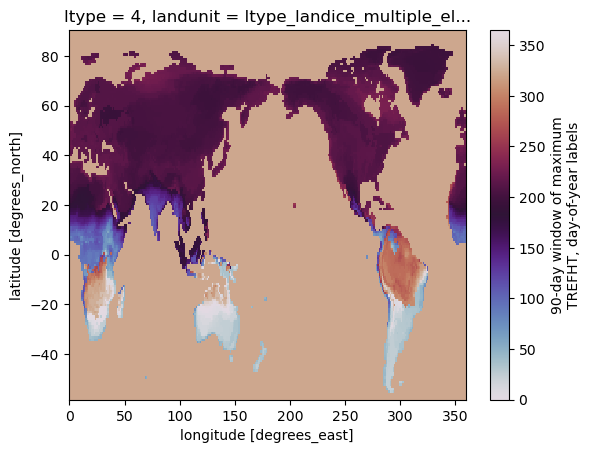

In [28]:
window_1deg.isel(window_day=45, member=0).sel(lat=slice(-58, 90)).plot(vmin=0, vmax=365, cmap="twilight")

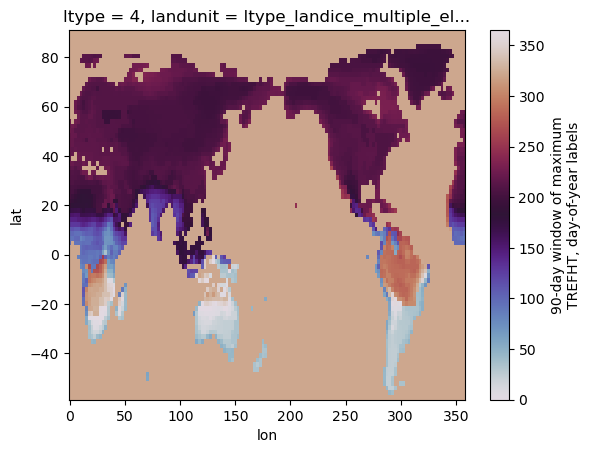

In [27]:
window_2deg.isel(window_day=45, member=0).sel(lat=slice(-58, 90)).plot(vmin=0, vmax=365, cmap="twilight")

In [2]:
OUTPUT_PATH = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist")
FIG_PATH = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/fig/temp_extremes")

PROJECTION = ccrs.PlateCarree(central_longitude=12)

MAP_SUBPLOT_KWARGS = {"figsize": (8, 4), "subplot_kw": {"projection": PROJECTION}}
MAP_SUBPLOTS_KWARGS = {
    "fhist": {"ncols": 7, "nrows": 4, "figsize": (21, 7), "subplot_kw": {"projection": PROJECTION}},
    "goga2": {"ncols": 5, "nrows": 2, "figsize": (18, 4), "subplot_kw": {"projection": PROJECTION}},
    "lens2": {"ncols": 7, "nrows": 6, "figsize": (21, 12), "subplot_kw": {"projection": PROJECTION}},
}

LAT_BNDS = slice(-58, 90)
MAP_LAT_BNDS = slice(-54, 90)

CMAPS = {
    "cyclic": "twilight",
    "range": "magma_r",
    "temp": "inferno",
    "temp_diff": "RdBu_r",
}

COLORS = {
    "fhist": "tab:blue",
    "goga2": "indianred",
    "lens2": "tab:orange",
}

GRID = {
    "fhist": xclim.load_fhist_ppe_grid(),
    "lens2": xclim.load_cesm2le_grid(),
    "goga2": xclim.load_goga2_grid(),
}

QUANTILES = [0.05, 0.25, 0.5, 0.75, 0.95]

UNITS = "\u00B0C"

GRIDCELLS = {
    "ngp": dict(lon=263, lat=50, method="nearest"),
    "eus": dict(lon=280, lat=39, method="nearest"),
    "amz": dict(lon=295, lat=0, method="nearest"),
    "nru": dict(lon=120, lat=63, method="nearest"),
    "ukr": dict(lon=42, lat=50, method="nearest"),
    "cng": dict(lon=22, lat=0, method="nearest"),
    "gui": dict(lon=140, lat=-5, method="nearest"),
    "aus": dict(lon=137, lat=-22, method="nearest"),
}

In [3]:
grid = xclim.load_fhist_ppe_grid().compute().sel(lat=LAT_BNDS)

mask = regmask.defined_regions.ar6.land.mask(grid.lon, grid.lat)
mask = xr.where((mask == 0) & (grid.LANDAREA > 0), False, grid.LANDAREA > 0)

In [4]:
window = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/doy_climatology/FHIST_TREFHT_pool_30d_window_19850101-20141231_doy_window.nc").sel(lat=LAT_BNDS).where(mask)

kde_raw = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/FHIST_TREFHT_pool_30d_window_19850101-20141231_kde.nc").sel(lat=LAT_BNDS).where(mask)
stats_raw = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/FHIST_TREFHT_pool_30d_window_19850101-20141231_stats.nc").sel(lat=LAT_BNDS).where(mask)

kde_anom = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/FHIST_TREFHT_pool_30d_window_19850101-20141231_anom_kde.nc").sel(lat=LAT_BNDS).where(mask)
stats_anom = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/FHIST_TREFHT_pool_30d_window_19850101-20141231_anom_stats.nc").sel(lat=LAT_BNDS).where(mask)

In [41]:
def cyclic_diff(a, b, period=365):
    return ((a - b) + period/2) % period - period / 2


window_days = 30
dataset = "fhist"
variable = "TREFHT"

# Compute the central day of the n-day window and range in the central day
window_center = window.max_window_doy.sel(window_day=window_days // 2).where(mask)
window_center_range = cyclic_diff(window_center.max(dim="member"), window_center.min(dim="member"))
window_center_delta = cyclic_diff(window_center.isel(member=slice(1, None)), window_center.isel(member=0))

# Compute the change in quantiles between ensemble members
quantiles_anom_delta = stats_anom.quantiles - stats_anom.quantiles.isel(member=0)
quantiles_raw_delta = stats_raw.quantiles - stats_raw.quantiles.isel(member=0)

# Compute the change in mean
mu_raw_delta = stats_raw.mu - stats_raw.mu.isel(member=0)

# Compute the ratios of tail metrics (0.05 and 0.95 quantiles) to center metrics (mean and median)
p_mu_ratio = quantiles_anom_delta / mu_raw_delta
p_50p_ratio = quantiles_anom_delta.sel(quantile=[0.05, 0.95]) / quantiles_raw_delta.sel(quantile=0.50)

# Compute the quantile shift between members
qshift_left = stats_anom.quantiles.sel(quantile=0.50) - stats_anom.quantiles.sel(quantile=0.05)
qshift_right = stats_anom.quantiles.sel(quantile=0.95) - stats_anom.quantiles.sel(quantile=0.50)

# Compute the change in quantile shift relative the center (median)
qshift_left_delta = qshift_left - qshift_left.isel(member=0)
qshift_right_delta =  qshift_right - qshift_right.isel(member=0)
qshift_delta_symmetry = qshift_right_delta - qshift_left_delta

# Compute the range in quantiles and center metrics across the ensemble
quantiles_anom_range = stats_anom.quantiles.max(dim="member") - stats_anom.quantiles.min(dim="member")
mu_raw_range = stats_raw.mu.max(dim="member") - stats_raw.mu.min(dim="member")

NameError: name 'quantiles_anom_delta' is not defined

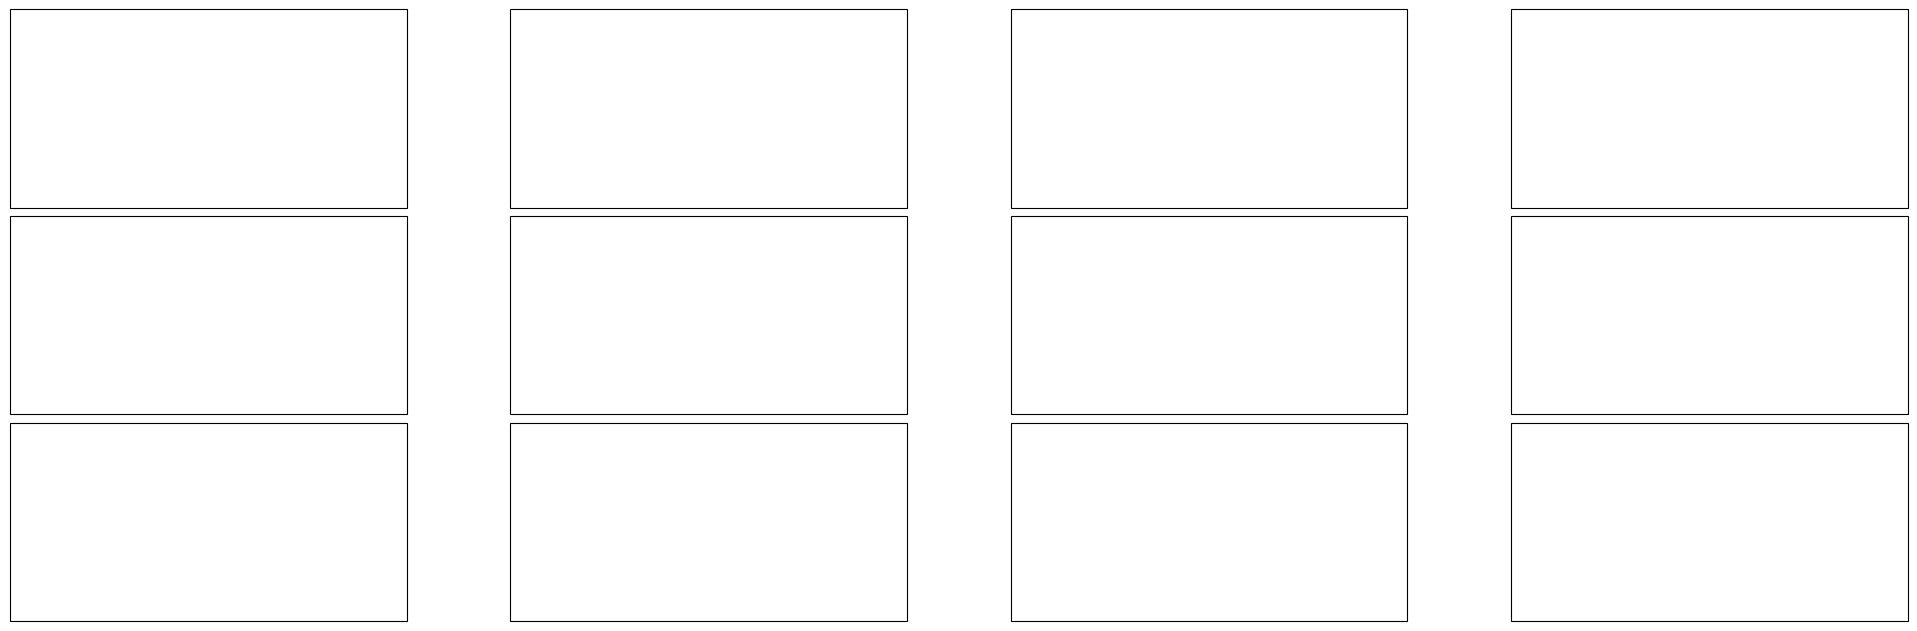

In [29]:
def share_colorbar_limits(da_list, sym):
    shared_vmin = xr.concat(da_list, dim="_panel").quantile(0.05, skipna=True)
    shared_vmax = xr.concat(da_list, dim="_panel").quantile(0.95, skipna=True)
    if sym:
        shared_vabs = max([abs(shared_vmin), abs(shared_vmax)])
        return -shared_vabs, shared_vabs
    return shared_vmin, shared_vmax

m = 9

fig, axes = plt.subplots(
    3, 4, figsize=(20, 6.2), layout="constrained",
    subplot_kw={"projection": PROJECTION},
)
axs = axes.ravel()

xr_subplot_kwargs = dict(robust=True, cbar_kwargs={"shrink": 1, "extend": "both"}, add_labels=False, transform=ccrs.PlateCarree())

panel20 = qshift_left.sel(member=m)
panel21 = qshift_right.sel(member=m)
panel_20_21_vmin, panel_20_21_vmax = share_colorbar_limits([panel20, panel21], sym=False)

panel02 = quantiles_anom_delta.sel(quantile=0.50, member=m)
panel12 = quantiles_anom_delta.sel(quantile=0.05, member=m)
panel13 = quantiles_anom_delta.sel(quantile=0.95, member=m)
panel_02_12_13_vmin, panel_02_12_13_vmax = share_colorbar_limits([panel02, panel12, panel13], sym=True)

panel22 = qshift_left_delta.sel(member=m)
panel23 = qshift_right_delta.sel(member=m)
panel_22_23_vmin, panel_22_23_vmax = share_colorbar_limits([panel22, panel23], sym=True)

# Left block
stats_anom.quantiles.sel(quantile=0.50, member=m).plot(ax=axes[0,0], **xr_subplot_kwargs)
mu_raw_delta.sel(member=m).plot(ax=axes[0,1], cmap="RdBu_r", **xr_subplot_kwargs)

stats_anom.quantiles.sel(quantile=0.05, member=m).plot(ax=axes[1,0], **xr_subplot_kwargs)
stats_anom.quantiles.sel(quantile=0.95, member=m).plot(ax=axes[1,1], **xr_subplot_kwargs)

panel20.plot(ax=axes[2,0], vmin=panel_20_21_vmin, vmax=panel_20_21_vmax, **xr_subplot_kwargs)
panel21.plot(ax=axes[2,1], vmin=panel_20_21_vmin, vmax=panel_20_21_vmax, **xr_subplot_kwargs)

# Right block
panel02.plot(ax=axes[0,2], vmin=panel_02_12_13_vmin, vmax=panel_02_12_13_vmax, cmap="RdBu_r", **xr_subplot_kwargs)
qshift_delta_symmetry.sel(member=m).plot(ax=axes[0,3], cmap="RdBu_r", **xr_subplot_kwargs)

panel12.plot(ax=axes[1,2], vmin=panel_02_12_13_vmin, vmax=panel_02_12_13_vmax, cmap="RdBu_r", **xr_subplot_kwargs)
panel13.plot(ax=axes[1,3], vmin=panel_02_12_13_vmin, vmax=panel_02_12_13_vmax, cmap="RdBu_r", **xr_subplot_kwargs)

panel22.plot(ax=axes[2,2], vmin=panel_22_23_vmin, vmax=panel_22_23_vmax, cmap="RdBu_r", **xr_subplot_kwargs)
panel23.plot(ax=axes[2,3], vmin=panel_22_23_vmin, vmax=panel_22_23_vmax, cmap="RdBu_r", **xr_subplot_kwargs)

axes[0,0].set_title(f"{variable}'_50p")
axes[0,1].set_title(f"$\\Delta${variable}_avg")
axes[0,2].set_title(f"$\\Delta${variable}'_50p")
axes[0,3].set_title(f"R $-$ L")

axes[1,0].set_title(f"{variable}'_05p")
axes[1,1].set_title(f"{variable}'_95p")
axes[1,2].set_title(f"$\\Delta${variable}'_05p")
axes[1,3].set_title(f"$\\Delta${variable}'_95p")

axes[2,0].set_title(f"{variable}'_50p $-$ {variable}'_05p")
axes[2,1].set_title(f"{variable}'_95p $-$ {variable}'_50p")
axes[2,2].set_title(f"L = $\\Delta$({variable}'_50p $-$ {variable}'_05p)")
axes[2,3].set_title(f"R = $\\Delta$({variable}'_95p $-$ {variable}'_50p)")

for ax in axs:
    ax.coastlines(color="k", lw=0.8)
    ax.set_extent((-180, 180, -58, 90), crs=PROJECTION)
    ax.gridlines(
        draw_labels=False,
        xlocs=np.arange(-180, 181, 30),
        ylocs=np.linspace(LAT_BNDS.start, LAT_BNDS.stop, 6),
        linewidth=0.5,
        color="gray",
        alpha=0.6,
        linestyle="--",
    )

fig.suptitle(f"{dataset.upper()}, {window_days}-day window, {variable} [{UNITS}], {int(m):02d}", fontweight="bold")

In [7]:
goga_null = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_90d_window/GOGA2_TREFHT_pool_90d_window_19850101-20141231_null.nc").sel(lat=LAT_BNDS)

qdelta_median_max_goga = goga_null.delta_median.max(dim="pair")
qshift_left_max_goga = goga_null.left_shift.max(dim="pair")
qshift_right_max_goga = goga_null.right_shift.max(dim="pair")
symmetry_max_goga = goga_null.symmetry.max(dim="pair")

qdelta_median_std_goga = goga_null.delta_median.std(dim="pair")
qshift_left_std_goga = goga_null.left_shift.std(dim="pair")
qshift_right_std_goga = goga_null.right_shift.std(dim="pair")
symmetry_std_goga = goga_null.symmetry.std(dim="pair")

In [ ]:
# Compute the change in quantiles between ensemble members
qdelta = stats_anom.quantiles - stats_anom.quantiles.isel(member=0)
qdelta_median = qdelta.sel(quantile=0.50)

# Compute the quantile shift
qdelta_shift_left = qdelta.sel(quantile=0.50) - qdelta.sel(quantile=0.05)
qdelta_shift_right = qdelta.sel(quantile=0.95) - qdelta.sel(quantile=0.50)
qdelta_symmetry = qdelta_shift_right - qdelta_shift_left

# Compute masks for GOGA2 range > 0.75
qdelta_median_goga_mask = xr.where(abs(qdelta_median_max_goga) > 0.75, 1.0, np.nan)
qdelta_left_goga_mask = xr.where(abs(qshift_left_max_goga) > 0.75, 1.0, np.nan)
qdelta_right_goga_mask = xr.where(abs(qshift_right_max_goga) > 0.75, 1.0, np.nan)
qdelta_symmetry_goga_mask = xr.where(abs(symmetry_max_goga) > 0.75, 1.0, np.nan)


# x = qshift_right_max_goga
# ax = plt.gca()
# hatch_mask = xr.where(abs(x) > 0.75, 1.0, np.nan)
# hatch_mask.plot.contourf(
#     ax=ax,
#     levels=[0.5, 1.5],
#     colors="none",
#     hatches=["////"],
#     add_colorbar=False,
# )

In [91]:
def add_hatching(x, ax, thresh=0.50, hatches=["/////"]):
    hatch_mask = xr.where(abs(x) > thresh, 1.0, np.nan)
    hatch_mask.plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],
        colors="none",
        hatches=hatches,
        add_colorbar=False,
        transform=ccrs.PlateCarree(),
    )

In [ ]:
qdelta_shift_left

Text(0.5, 0.98, 'FHIST, 30-day window, TREFHT [°C], 4.d_max.max')

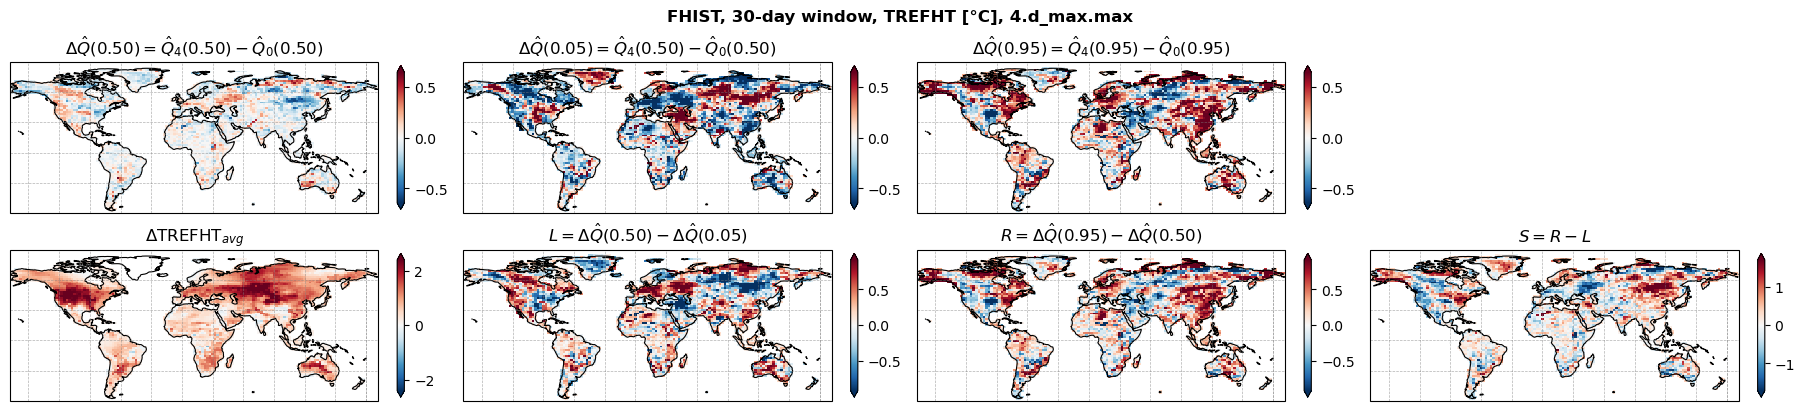

In [105]:
dataset = "fhist"
variable = "TREFHT"
window_days = 30

# Load data
window = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/doy_climatology/FHIST_TREFHT_pool_30d_window_19850101-20141231_doy_window.nc").sel(lat=LAT_BNDS)
kde_raw = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/FHIST_TREFHT_pool_30d_window_19850101-20141231_kde.nc").sel(lat=LAT_BNDS)
stats_raw = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/FHIST_TREFHT_pool_30d_window_19850101-20141231_stats.nc").sel(lat=LAT_BNDS)
kde_anom = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/FHIST_TREFHT_pool_30d_window_19850101-20141231_anom_kde.nc").sel(lat=LAT_BNDS)
stats_anom = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/FHIST_TREFHT_pool_30d_window_19850101-20141231_anom_stats.nc").sel(lat=LAT_BNDS)
goga_null = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_90d_window/GOGA2_TREFHT_pool_90d_window_19850101-20141231_null.nc").sel(lat=LAT_BNDS)


# Compute the central day of the n-day window and range in the central day
window_center = window.max_window_doy.sel(window_day=window_days // 2).where(mask)
window_center_range = cyclic_diff(window_center.max(dim="member"), window_center.min(dim="member"))
window_center_delta = cyclic_diff(window_center.isel(member=slice(1, None)), window_center.isel(member=0))

# Compute the change in mean
delta_mu = stats_raw.mu - stats_raw.mu.isel(member=0)

# Compute the change in quantiles between ensemble members
qdelta = stats_anom.quantiles - stats_anom.quantiles.isel(member=0)

# Compute the quantile shift
qdelta_shift_left = qdelta.sel(quantile=0.50) - qdelta.sel(quantile=0.05)
qdelta_shift_right = qdelta.sel(quantile=0.95) - qdelta.sel(quantile=0.50)
qdelta_symmetry = qdelta_shift_right - qdelta_shift_left

# Compute the null pool statistics
qdelta_median_max_goga = goga_null.delta_median.max(dim="pair")
qdelta_left_shift_max_goga = goga_null.left_shift.max(dim="pair")
qdelta_right_shift_max_goga = goga_null.right_shift.max(dim="pair")
qdelta_symmetry_max_goga = goga_null.symmetry.max(dim="pair")


def add_hatching(x, ax, thresh=0.50, hatches=["/////"]):
    hatch_mask = xr.where(abs(x) < thresh, 1.0, np.nan)
    hatch_mask.plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],
        colors="none",
        hatches=hatches,
        add_colorbar=False,
        transform=ccrs.PlateCarree(),
    )



m = 4


fig, axes = plt.subplots(
    2, 4, figsize=(18, 4), layout="constrained",
    subplot_kw={"projection": PROJECTION},
)
axs = axes.ravel()

xr_subplot_kwargs = dict(robust=True, cbar_kwargs={"shrink": 0.95, "extend": "both"}, add_labels=False, transform=ccrs.PlateCarree())

qdelta_panels = [
    qdelta.sel(quantile=0.05, member=m),
    qdelta.sel(quantile=0.50, member=m),
    qdelta.sel(quantile=0.95, member=m),
]
qdelta_vmin, qdelta_vmax = share_colorbar_limits(qdelta_panels, sym=True)

qdelta_shift_panels = [
    qdelta_shift_left.sel(member=m),
    qdelta_shift_right.sel(member=m),
]
qdelta_shift_vmin, qdelta_shift_vmax = share_colorbar_limits(qdelta_shift_panels, sym=True)

qdelta.sel(quantile=0.50, member=m).plot(ax=axs[0], vmin=qdelta_vmin, vmax=qdelta_vmax, cmap="RdBu_r", **xr_subplot_kwargs)
qdelta.sel(quantile=0.05, member=m).plot(ax=axs[1], vmin=qdelta_vmin, vmax=qdelta_vmax, cmap="RdBu_r", **xr_subplot_kwargs)
qdelta.sel(quantile=0.95, member=m).plot(ax=axs[2], vmin=qdelta_vmin, vmax=qdelta_vmax, cmap="RdBu_r", **xr_subplot_kwargs)

mu_raw_delta.sel(member=m).plot(ax=axs[4], **xr_subplot_kwargs)
qdelta_shift_left.sel(member=m).plot(ax=axs[5], vmin=qdelta_shift_vmin, vmax=qdelta_shift_vmax, cmap="RdBu_r", **xr_subplot_kwargs)
qdelta_shift_right.sel(member=m).plot(ax=axs[6], vmin=qdelta_shift_vmin, vmax=qdelta_shift_vmax, cmap="RdBu_r", **xr_subplot_kwargs)
qdelta_symmetry.sel(member=m).plot(ax=axs[7], **xr_subplot_kwargs)

# add_hatching(qdelta_left_shift_max_goga, axs[5], thresh=0.5)
# add_hatching(qdelta_right_shift_max_goga, axs[6], thresh=0.5)
# add_hatching(qdelta_symmetry_max_goga, axs[7], thresh=1)

axs[0].set_title(f"$\\Delta\\hat{{Q}}(0.50) = \\hat{{Q}}_{{{int(m):d}}}(0.50) - \\hat{{Q}}_{{0}}(0.50)$")
axs[1].set_title(f"$\\Delta\\hat{{Q}}(0.05) = \\hat{{Q}}_{{{int(m):d}}}(0.50) - \\hat{{Q}}_{{0}}(0.50)$")
axs[2].set_title(f"$\\Delta\\hat{{Q}}(0.95) = \\hat{{Q}}_{{{int(m):d}}}(0.95) - \\hat{{Q}}_{{0}}(0.95)$")
axs[4].set_title(f"$\\Delta${variable.upper()}$_{{avg}}$")
axs[5].set_title("$L = \\Delta\\hat{{Q}}(0.50) - \\Delta\\hat{{Q}}(0.05)$")
axs[6].set_title("$R = \\Delta\\hat{{Q}}(0.95) - \\Delta\\hat{{Q}}(0.50)$")
axs[7].set_title("$S = R - L$")

for ax in axs:
    ax.coastlines(color="k", lw=0.8)
    ax.set_extent((-180, 180, -58, 90), crs=PROJECTION)
    ax.gridlines(
        draw_labels=False,
        xlocs=np.arange(-180, 181, 30),
        ylocs=np.linspace(LAT_BNDS.start, LAT_BNDS.stop, 6),
        linewidth=0.5,
        color="gray",
        alpha=0.6,
        linestyle="--",
    )

axs[3].remove()

fig.suptitle(f"{dataset.upper()}, {window_days}-day window, {variable} [{UNITS}], {xclim.ppe.get_member_name(m)}", fontweight="bold")

Text(0.5, 0.98, 'GOGA2, 30-day window, TREFHT [°C], pairwise null pool')

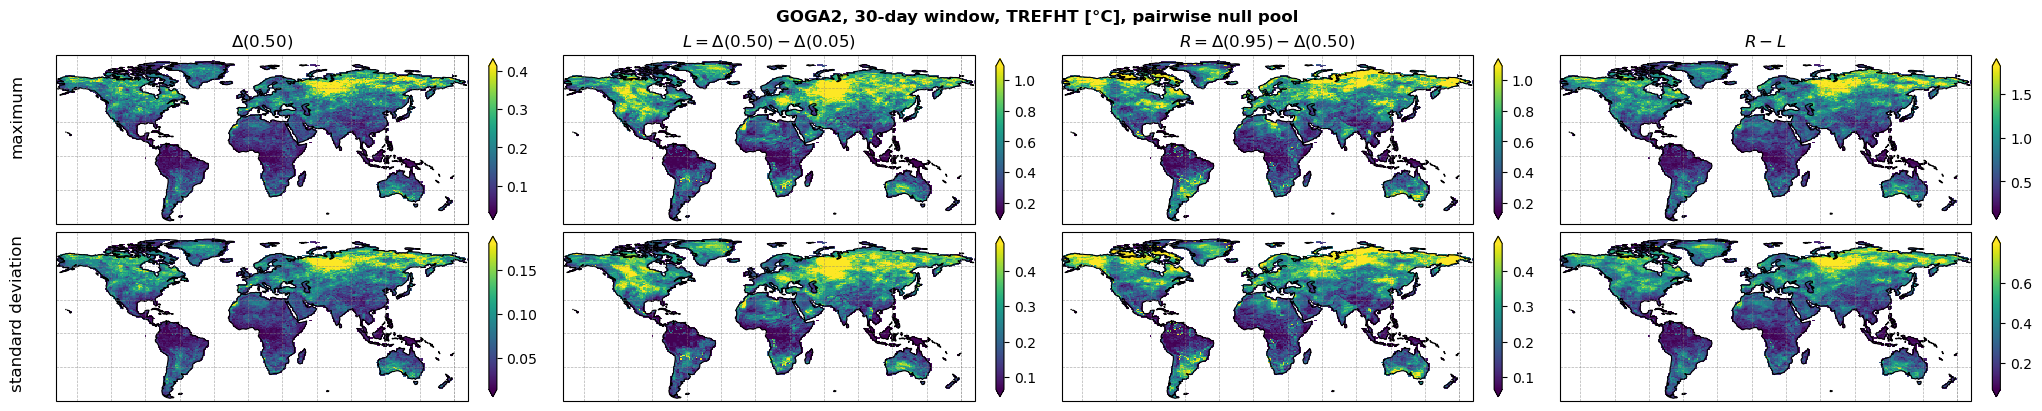

In [223]:
fig, axes = plt.subplots(
    2, 4, figsize=(20, 4), layout="constrained",
    subplot_kw={"projection": PROJECTION},
)
axs = axes.ravel()

xr_subplot_kwargs = dict(robust=True, cbar_kwargs={"shrink": 0.95, "extend": "both"}, add_labels=False, transform=ccrs.PlateCarree())

shift_max_vmin, shift_max_vmax = share_colorbar_limits([left_shift_max_goga, right_shift_max_goga], sym=False)
shift_std_vmin, shift_std_vmax = share_colorbar_limits([qshift_left_shift_std_goga, qshift_right_shift_std_goga], sym=False)

delta_median_max_goga.plot(ax=axs[0], **xr_subplot_kwargs)
left_shift_max_goga.plot(ax=axs[1], vmin=shift_max_vmin, vmax=shift_max_vmax, **xr_subplot_kwargs)
right_shift_max_goga.plot(ax=axs[2], vmin=shift_max_vmin, vmax=shift_max_vmax, **xr_subplot_kwargs)
symmetry_max_goga.plot(ax=axs[3], **xr_subplot_kwargs)

delta_median_std_goga.plot(ax=axs[4], **xr_subplot_kwargs)
qshift_left_shift_std_goga.plot(ax=axs[5], vmin=shift_std_vmin, vmax=shift_std_vmax, **xr_subplot_kwargs)
qshift_right_shift_std_goga.plot(ax=axs[6], vmin=shift_std_vmin, vmax=shift_std_vmax, **xr_subplot_kwargs)
qshift_symmetry_std_goga.plot(ax=axs[7], **xr_subplot_kwargs)

axs[0].set_title("$\\Delta (0.50)$")
axs[1].set_title("$L = \\Delta(0.50) - \\Delta(0.05)$")
axs[2].set_title("$R = \\Delta(0.95) - \\Delta(0.50)$")
axs[3].set_title("$R - L$")

fig.text(
    -0.01, 0.725,
    "maximum",
    rotation=90,
    ha="center", va="center",
    fontsize=12
)
fig.text(
    -0.01, 0.23,
    "standard deviation",
    rotation=90,
    ha="center", va="center",
    fontsize=12
)

for ax in axs:
    ax.coastlines(color="k", lw=0.8)
    ax.set_extent((-180, 180, -58, 90), crs=PROJECTION)
    ax.gridlines(
        draw_labels=False,
        xlocs=np.arange(-180, 181, 30),
        ylocs=np.linspace(LAT_BNDS.start, LAT_BNDS.stop, 6),
        linewidth=0.5,
        color="gray",
        alpha=0.6,
        linestyle="--",
    )

fig.suptitle(f"GOGA2, {window_days}-day window, {variable} [{UNITS}], pairwise null pool", fontweight="bold")

In [ ]:
fig, axes = plt.subplots(
    2, 4, figsize=(20, 4), layout="constrained",
    subplot_kw={"projection": PROJECTION},
)
axs = axes.ravel()

xr_subplot_kwargs = dict(robust=True, cbar_kwargs={"shrink": 0.95, "extend": "both"}, add_labels=False, transform=ccrs.PlateCarree())

shift_max_vmin, shift_max_vmax = share_colorbar_limits([left_shift_max_goga, right_shift_max_goga], sym=False)
shift_std_vmin, shift_std_vmax = share_colorbar_limits([qshift_left_shift_std_goga, qshift_right_shift_std_goga], sym=False)

delta_median_max_goga.plot(ax=axs[0], **xr_subplot_kwargs)
left_shift_max_goga.plot(ax=axs[1], vmin=shift_max_vmin, vmax=shift_max_vmax, **xr_subplot_kwargs)
right_shift_max_goga.plot(ax=axs[2], vmin=shift_max_vmin, vmax=shift_max_vmax, **xr_subplot_kwargs)
symmetry_max_goga.plot(ax=axs[3], **xr_subplot_kwargs)

delta_median_std_goga.plot(ax=axs[4], **xr_subplot_kwargs)
qshift_left_shift_std_goga.plot(ax=axs[5], vmin=shift_std_vmin, vmax=shift_std_vmax, **xr_subplot_kwargs)
qshift_right_shift_std_goga.plot(ax=axs[6], vmin=shift_std_vmin, vmax=shift_std_vmax, **xr_subplot_kwargs)
qshift_symmetry_std_goga.plot(ax=axs[7], **xr_subplot_kwargs)

axs[0].set_title("$\\Delta (0.50)$")
axs[1].set_title("$L = \\Delta(0.50) - \\Delta(0.05)$")
axs[2].set_title("$R = \\Delta(0.95) - \\Delta(0.50)$")
axs[3].set_title("$R - L$")

fig.text(
    -0.01, 0.725,
    "maximum",
    rotation=90,
    ha="center", va="center",
    fontsize=12
)
fig.text(
    -0.01, 0.23,
    "standard deviation",
    rotation=90,
    ha="center", va="center",
    fontsize=12
)

for ax in axs:
    ax.coastlines(color="k", lw=0.8)
    ax.set_extent((-180, 180, -58, 90), crs=PROJECTION)
    ax.gridlines(
        draw_labels=False,
        xlocs=np.arange(-180, 181, 30),
        ylocs=np.linspace(LAT_BNDS.start, LAT_BNDS.stop, 6),
        linewidth=0.5,
        color="gray",
        alpha=0.6,
        linestyle="--",
    )

fig.suptitle(f"GOGA2, {window_days}-day window, {variable} [{UNITS}], pairwise null pool", fontweight="bold")

In [ ]:
grid = xclim.load_goga2_grid().compute()

window = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/doy_climatology/GOGA2_TREFHT_pool_30d_window_19850101-20141231_doy_window.nc")

kde_raw = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/GOGA2_TREFHT_pool_30d_window_19850101-20141231_kde.nc")
stats_raw = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/GOGA2_TREFHT_pool_30d_window_19850101-20141231_stats.nc")

kde_anom = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/GOGA2_TREFHT_pool_30d_window_19850101-20141231_anom_kde.nc")
stats_anom = xr.open_dataset("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_30d_window/GOGA2_TREFHT_pool_30d_window_19850101-20141231_anom_stats.nc")


quantiles_anom_delta = stats_anom.quantiles.isel(member=slice(1, None)) - stats_anom.quantiles.isel(member=0)
mu_raw_delta = stats_raw.mu.isel(member=slice(1, None)) - stats_raw.mu.isel(member=0)
p_mu_ratio = quantiles_anom_delta / mu_raw_delta

min_tail = (stats_anom.quantiles.sel(quantile=0.05) - stats_anom.quantiles.sel(quantile=0.50)).sel(lat=slice(-58, None))
max_tail = (stats_anom.quantiles.sel(quantile=0.95) - stats_anom.quantiles.sel(quantile=0.50)).sel(lat=slice(-58, None))

delta_min_tail = min_tail.isel(member=slice(1, None)) - min_tail.isel(member=0)
delta_max_tail = max_tail.isel(member=slice(1, None)) - max_tail.isel(member=0)

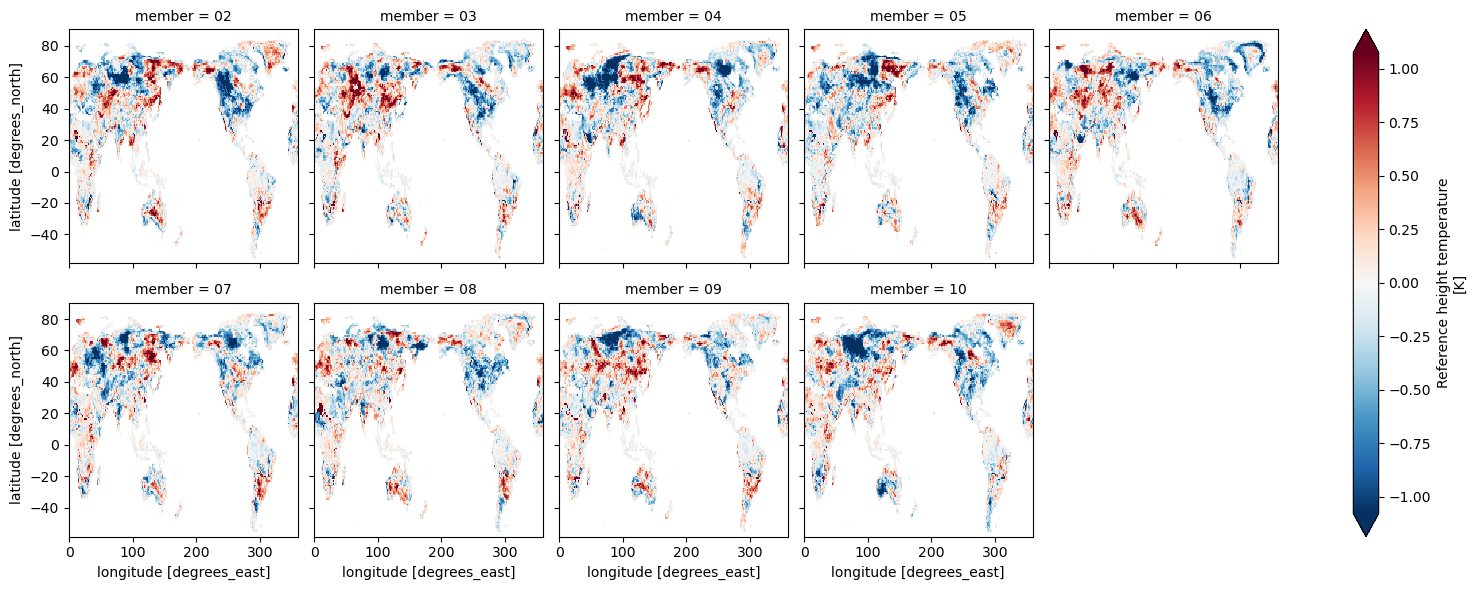

In [ ]:
delta_min_tail.plot(col="member", col_wrap=5, robust=True)

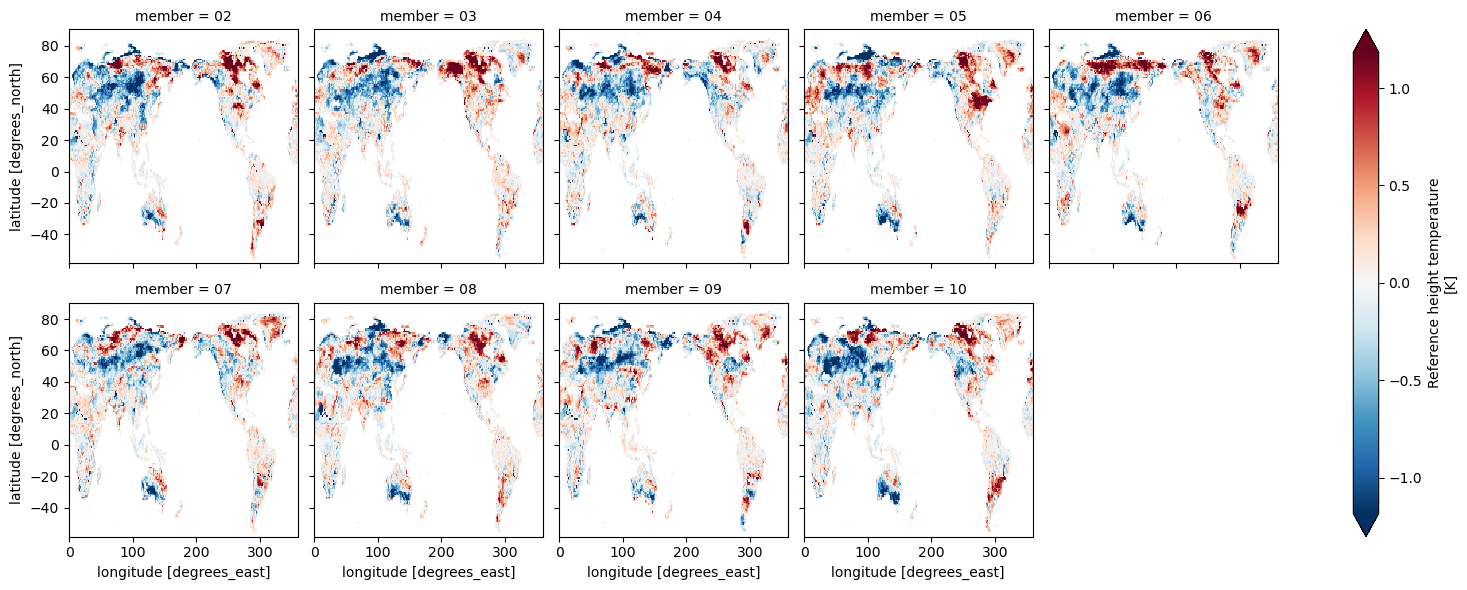

In [ ]:
delta_max_tail.plot(col="member", col_wrap=5, robust=True)

In [ ]:
PROJECTION = ccrs.PlateCarree(central_longitude=12)

MAP_SUBPLOT_KWARGS = {"figsize": (8, 4), "subplot_kw": {"projection": PROJECTION}}
MAP_SUBPLOTS_KWARGS = {
    "fhist": {"ncols": 7, "nrows": 4, "figsize": (21, 7), "subplot_kw": {"projection": PROJECTION}},
    "goga2": {"ncols": 5, "nrows": 2, "figsize": (18, 4), "subplot_kw": {"projection": PROJECTION}},
    "lens2": {"ncols": 7, "nrows": 6, "figsize": (21, 12), "subplot_kw": {"projection": PROJECTION}},
}

LAT_BNDS = slice(-58, 90)
MAP_LAT_BNDS = slice(-54, 90)

CMAPS = {
    "cyclic": "twilight",
    "range": "magma_r",
    "temp": "inferno",
    "temp_diff": "RdBu_r",
}

mem = window.member
n_mem = len(mem)
lat = window.lat
lon = window.lon

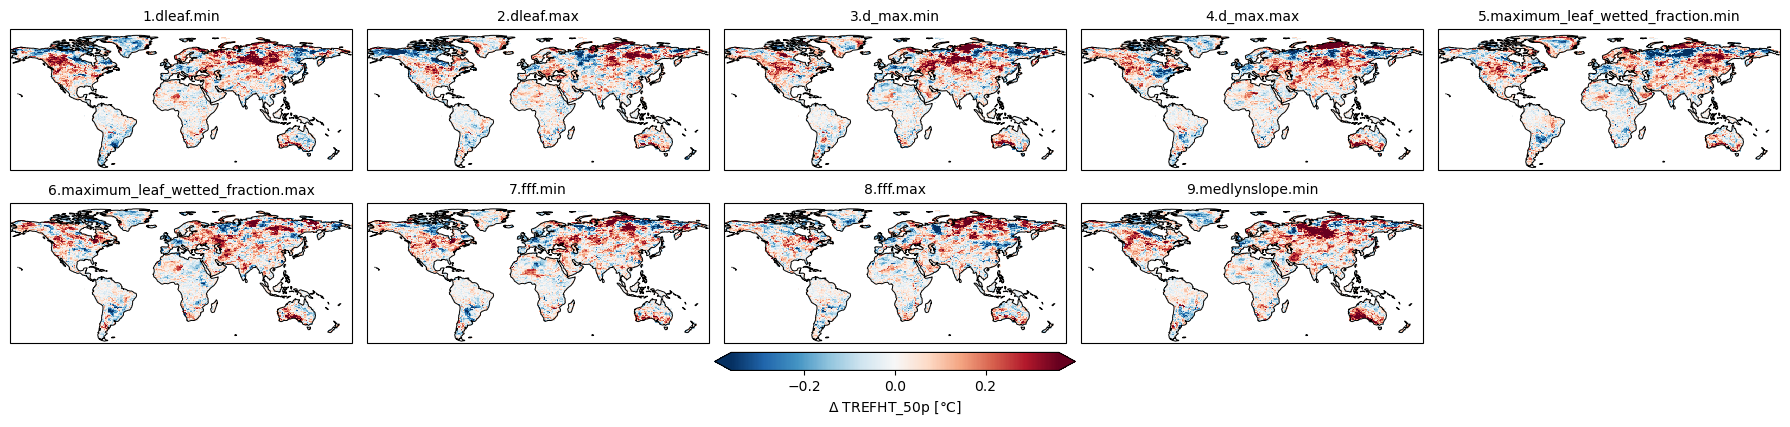

In [ ]:
q = 0.50

da = quantiles_anom_delta.sel(quantile=q, lat=MAP_LAT_BNDS)
fg = da.plot.pcolormesh(
    col="member",
    col_wrap=MAP_SUBPLOTS_KWARGS["goga2"].get("ncols", 4),
    subplot_kws=MAP_SUBPLOTS_KWARGS["goga2"]["subplot_kw"],
    figsize=MAP_SUBPLOTS_KWARGS["goga2"]["figsize"],
    transform=ccrs.PlateCarree(),
    cmap=CMAPS["temp_diff"],
    add_labels=False,
    cbar_kwargs={
        "orientation": "horizontal",
        "fraction": 0.05,
        "pad": 0.025,
        "label": f"$\\Delta$ TREFHT_{int(q*100):d}p [\u00B0C]",
    },
    robust=True,
)

for ax, m in zip(fg.axs.flat, mem.values):
    ax.set_title(xclim.ppe.get_member_name(m), fontsize=10)
    ax.set_extent([-180, 180, LAT_BNDS.start, LAT_BNDS.stop], crs=ccrs.PlateCarree())
    ax.coastlines(color="k", lw=0.7)

# Remove extra subplots
for i in range(1, len(fg.axs.flat) % n_mem + 1):
    fg.axs.flat[-i].remove()

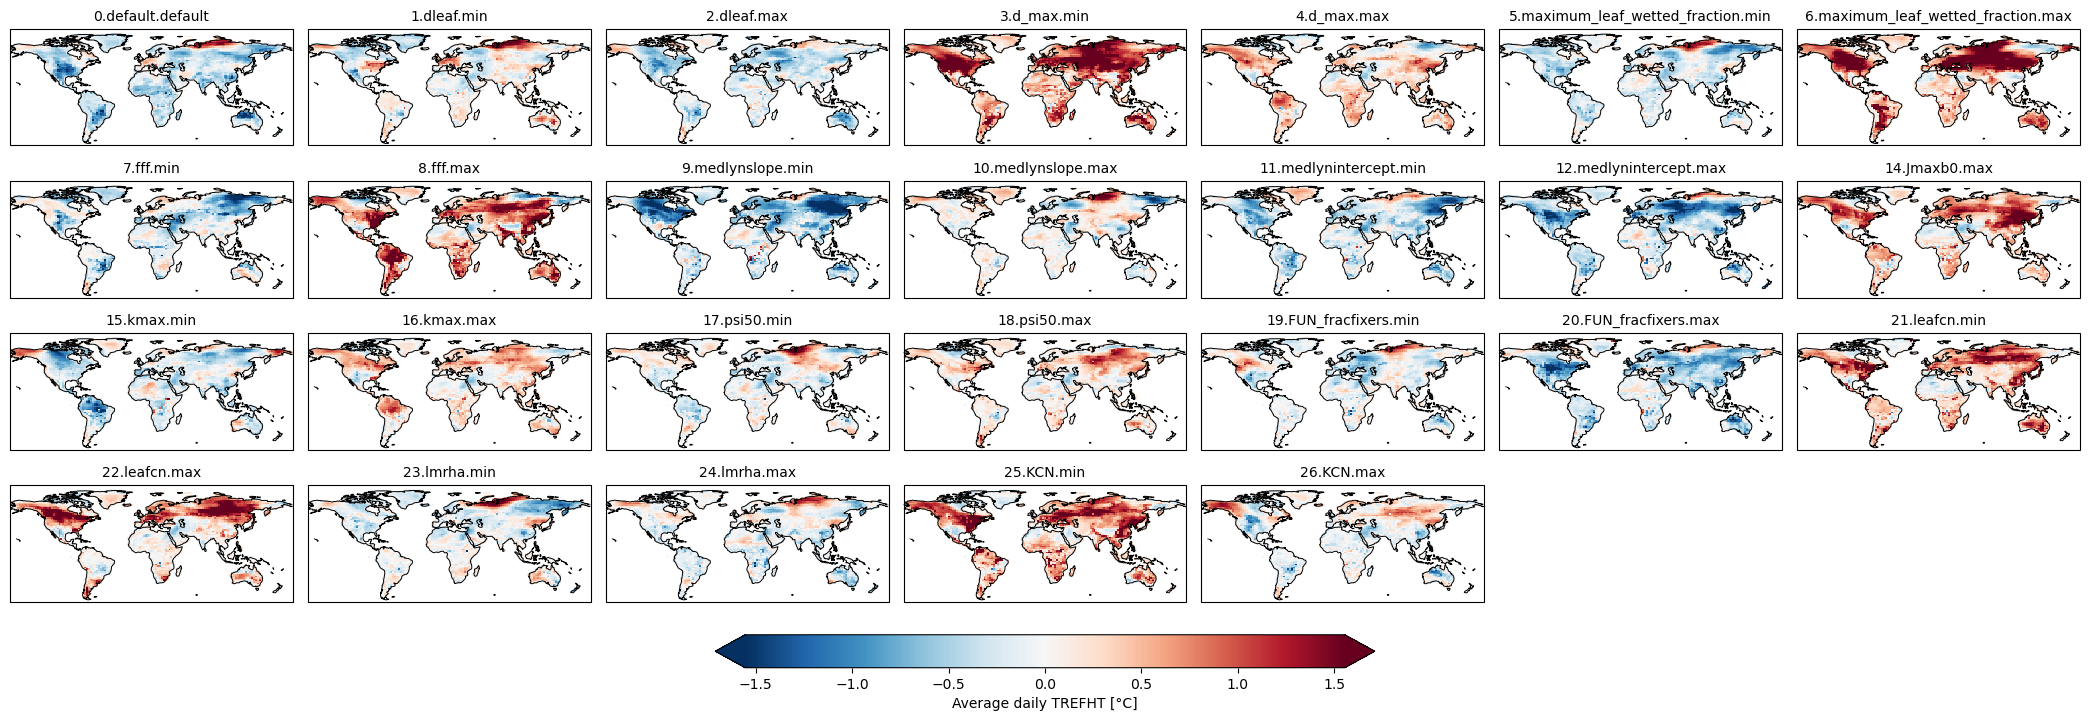

In [ ]:
da = mu_raw_delta.sel(lat=MAP_LAT_BNDS)
fg = da.plot.pcolormesh(
    col="member",
    col_wrap=MAP_SUBPLOTS_KWARGS["fhist"].get("ncols", 4),
    subplot_kws=MAP_SUBPLOTS_KWARGS["fhist"]["subplot_kw"],
    figsize=MAP_SUBPLOTS_KWARGS["fhist"]["figsize"],
    transform=ccrs.PlateCarree(),
    cmap=CMAPS["temp_diff"],
    add_labels=False,
    cbar_kwargs={
        "orientation": "horizontal",
        "fraction": 0.05,
        "pad": 0.05,
        "label": f"Average daily TREFHT [\u00B0C]",
    },
    robust=True,
)

for ax, m in zip(fg.axs.flat, mem.values):
    ax.set_title(xclim.ppe.get_member_name(m), fontsize=10)
    ax.set_extent([-180, 180, LAT_BNDS.start, LAT_BNDS.stop], crs=ccrs.PlateCarree())
    ax.coastlines(color="k", lw=0.7)

# Remove extra subplots
for i in range(1, len(fg.axs.flat) % n_mem + 1):
    fg.axs.flat[-i].remove()

In [ ]:
quantiles_anom_delta = stats_anom.quantiles.isel(member=slice(1, None)) - stats_anom.quantiles.isel(member=0)
mu_raw_delta = stats_raw.mu.isel(member=slice(1, None)) - stats_raw.mu.isel(member=0)
p_mu_ratio = quantiles_anom_delta / mu_raw_delta


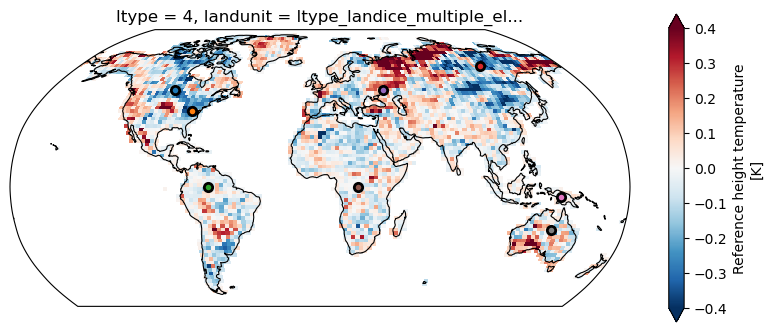

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4), subplot_kw={"projection": ccrs.Robinson()})
quantiles_anom_delta.sel(member=7, quantile=0.50, lat=slice(-54, None)).plot(ax=ax, robust=True, transform=ccrs.PlateCarree())
ax.scatter(263, 50, marker="o", edgecolor="k", facecolor=None, linewidth=2, transform=ccrs.PlateCarree())
ax.scatter(280, 39, marker="o", edgecolor="k", facecolor=None, linewidth=2, transform=ccrs.PlateCarree())
ax.scatter(295, 0, marker="o", edgecolor="k", facecolor=None, linewidth=2, transform=ccrs.PlateCarree())
ax.scatter(120, 63, marker="o", edgecolor="k", facecolor=None, linewidth=2, transform=ccrs.PlateCarree())
ax.scatter(42, 50, marker="o", edgecolor="k", facecolor=None, linewidth=2, transform=ccrs.PlateCarree())
ax.scatter(22, 0, marker="o", edgecolor="k", facecolor=None, linewidth=2, transform=ccrs.PlateCarree())
ax.scatter(140, -5, marker="o", edgecolor="k", facecolor=None, linewidth=2, transform=ccrs.PlateCarree())
ax.scatter(137, -22, marker="o", edgecolor="k", facecolor=None, linewidth=2, transform=ccrs.PlateCarree())
ax.coastlines(lw=0.8)